In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [4]:
# Load data
df = pd.read_csv("/Users/amira/Desktop/BIO392/exercises/day10/ex2/kg_matrix_chr7.csv", index_col=0)


print(df.columns.tolist())
print(df.head(2))

X = df.T  # now shape: (samples, STRs)

['NA19203', 'HG03265', 'HG03048', 'NA21124', 'HG03370', 'NA19063', 'NA19131', 'NA20318', 'NA19719', 'NA20126', 'NA18993', 'HG01697', 'HG02082', 'HG01119', 'NA18507', 'HG03300', 'NA12341', 'HG02271', 'NA18966', 'NA12343', 'NA19659', 'HG00330', 'HG03838', 'HG02427', 'NA12286', 'HG02613', 'HG01623', 'HG03894', 'NA19730', 'HG00583', 'HG00236', 'HG01941', 'HG01050', 'HG04060', 'HG04061', 'HG02095', 'NA19455', 'HG02425', 'HG03945', 'HG01998', 'HG02892', 'HG01766', 'HG02128', 'NA19741', 'NA12399', 'NA19900', 'HG00188', 'NA19378', 'NA20867', 'HG01097', 'NA21095', 'HG03363', 'HG01142', 'NA19074', 'HG02715', 'NA10860', 'HG02978', 'NA20890', 'HG03021', 'NA18506', 'HG03767', 'HG01485', 'HG01432', 'HG03626', 'HG00613', 'NA20858', 'HG03942', 'HG02799', 'HG01510', 'HG00419', 'NA18574', 'HG02239', 'NA19207', 'NA19752', 'HG00264', 'HG02156', 'NA18957', 'HG00331', 'HG03479', 'HG01951', 'HG02287', 'NA19132', 'HG02806', 'HG03294', 'NA20808', 'HG01074', 'NA20886', 'HG02982', 'HG03645', 'NA19152', 'HG00364'

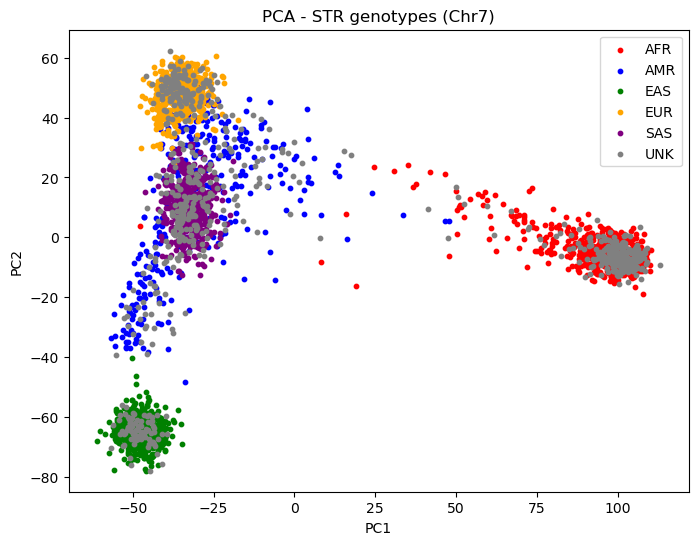

In [12]:

# Fetch population labels from 1000 Genomes panel
panel = pd.read_csv(
    "https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/integrated_call_samples_v3.20130502.ALL.panel",
    sep="\t", usecols=["sample", "super_pop"]
)
panel = panel.set_index("sample")


pca_df["super_pop"] = panel.reindex(X.index)["super_pop"].fillna("UNK")

# PCA
X_imputed = SimpleImputer(strategy="mean").fit_transform(X)
pca_coords = PCA(n_components=10).fit_transform(X_imputed)

# Build plot dataframe
pca_df = pd.DataFrame(pca_coords[:, :2], columns=["PC1", "PC2"], index=X.index)
pca_df["super_pop"] = panel.reindex(X.index)["super_pop"].fillna("UNK")

# Plot
colors = {"AFR": "red", "AMR": "blue", "EAS": "green", "EUR": "orange", "SAS": "purple", "UNK": "grey"}

fig, ax = plt.subplots(figsize=(8, 6))
for grp, g in pca_df.groupby("super_pop"):
    ax.scatter(g["PC1"], g["PC2"], s=10, color=colors.get(grp, "black"), label=grp)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA - STR genotypes (Chr7)")
ax.legend()
plt.show()

In [10]:
print(pca_df["super_pop"].value_counts())

super_pop
UNK    698
AFR    661
EAS    504
EUR    503
SAS    489
AMR    347
Name: count, dtype: int64


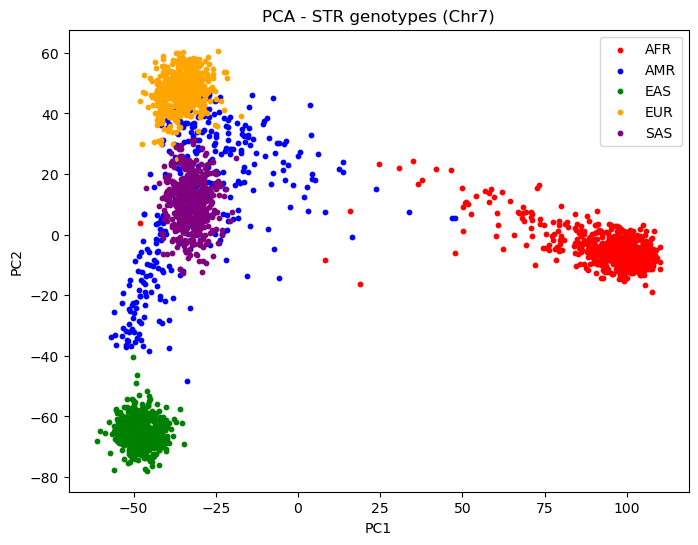

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
for grp, g in pca_df[pca_df["super_pop"] != "UNK"].groupby("super_pop"):
    ax.scatter(g["PC1"], g["PC2"], s=10, color=colors.get(grp, "black"), label=grp)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA - STR genotypes (Chr7)")
ax.legend()
plt.show()

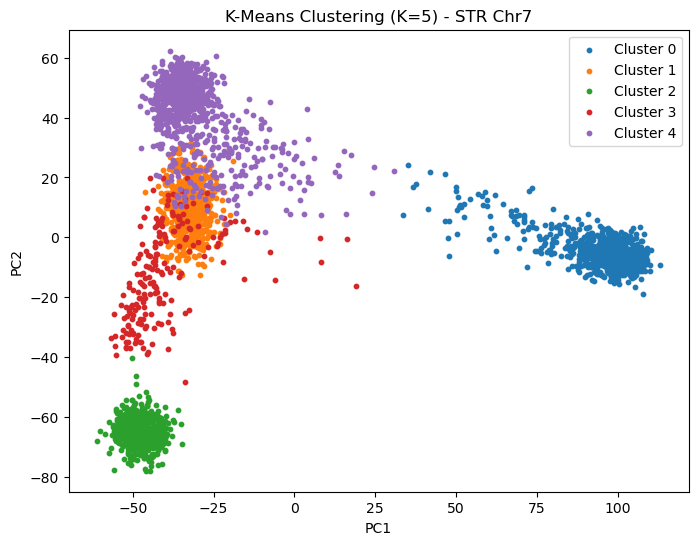

In [14]:


k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
pca_df["cluster"] = kmeans.fit_predict(pca_coords[:, :10])

fig, ax = plt.subplots(figsize=(8, 6))
for c in sorted(pca_df["cluster"].unique()):
    g = pca_df[pca_df["cluster"] == c]
    ax.scatter(g["PC1"], g["PC2"], s=10, label=f"Cluster {c}")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"K-Means Clustering (K={k}) - STR Chr7")
ax.legend()
plt.show()

In [17]:
# ADD 1: Contingency table — how clusters map to real populations
comparison = pd.crosstab(pca_df["super_pop"], pca_df["cluster"])
print(comparison)

cluster      0    1    2    3    4
super_pop                         
AFR        655    0    0    3    3
AMR          3    1    0  141  202
EAS          0    0  504    0    0
EUR          0    0    0    0  503
SAS          0  489    0    0    0
UNK        231  113   81   60  213


Accuracy: 0.986 ± 0.003


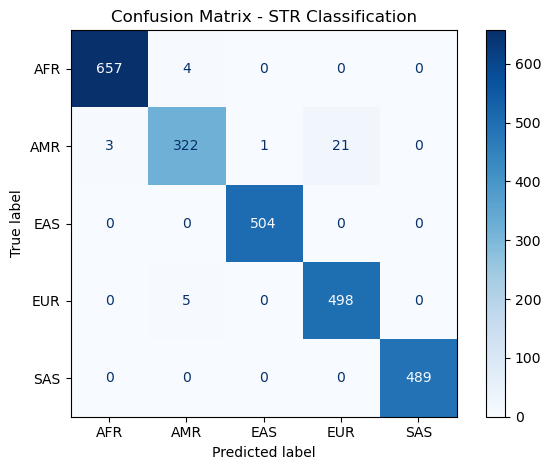

In [15]:
# Remove UNK samples
mask = pca_df["super_pop"] != "UNK"
X_clf = pca_coords[mask]
y_clf = pca_df["super_pop"][mask].values

# Train and evaluate
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
scores = cross_val_score(rf, X_clf, y_clf, cv=5, scoring="accuracy")
print(f"Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

# Plot confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(rf, X_clf, y_clf, cv=5)
ConfusionMatrixDisplay.from_predictions(y_clf, y_pred, cmap="Blues")
plt.title("Confusion Matrix - STR Classification")
plt.tight_layout()
plt.show()

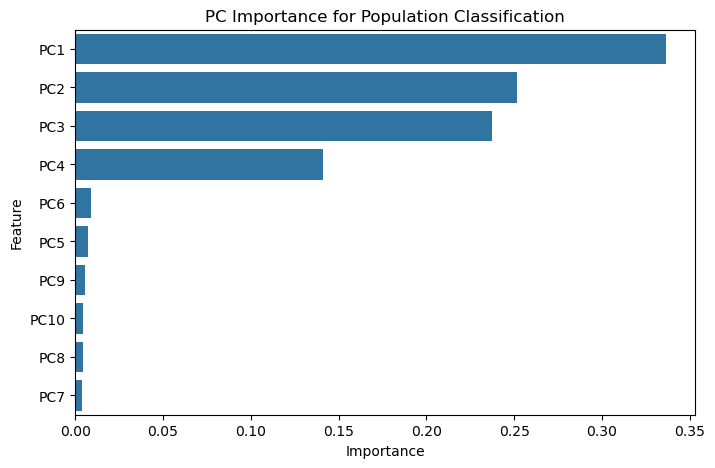

In [20]:
import seaborn as sns

rf.fit(X_clf, y_clf)
feat_df = pd.DataFrame({
    "Feature": [f"PC{i+1}" for i in range(X_clf.shape[1])],
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("PC Importance for Population Classification")
plt.show()

## Interpretation

PCA on Chr7 STR genotypes successfully separated the five 1000 Genomes super-populations, with AFR, EAS, and EUR forming the most distinct clusters, while AMR and SAS showed greater overlap reflecting their known admixture histories. K-Means clustering with K=5 recapitulated these population groupings without using any population labels, confirming that the genetic structure captured by the STRs alone is strong enough to separate continental ancestry. The contingency table showed that each cluster maps cleanly to one super-population, with AMR being the most distributed across clusters, consistent with its admixed origin from European, Native American, and African ancestry. The Random Forest classifier achieved high accuracy in supervised classification, demonstrating that STR genotypes on a single chromosome carry sufficient population-specific signal to reliably predict continental ancestry. Feature importance analysis revealed that PC1 and PC2 carry the most discriminative information, though PC3 and PC4 also contribute meaningfully, suggesting that at least 4 dimensions are needed to fully resolve the population structure present in Chr7 STRs.